<a href="https://colab.research.google.com/github/qjqj7890/Prompt-Engineering-Practice/blob/main/Prompt_Engineering_Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
!pip install newspaper3k lxml_html_clean -q

In [12]:
import requests

# 네이버 검색 API로 증시 뉴스 URL 수집
client_id = "J8M4B9zQ7ZPhHV6Gtx4I"
client_secret = "327i2WLwcQ"

url = "https://openapi.naver.com/v1/search/news.json"
params = {
    "query": "코스피 증시",
    "display": 20,
    "sort": "date"
}
headers = {
    "X-Naver-Client-Id": client_id,
    "X-Naver-Client-Secret": client_secret
}

res = requests.get(url, params=params, headers=headers)
items = res.json()["items"]

# 본문 추출
from newspaper import Article

articles = []
for item in items[:10]:
    try:
        a = Article(item["link"], language="ko")
        a.download()
        a.parse()
        articles.append({
            "title": item["title"],
            "content": a.text[:500]
        })
    except:
        pass

print(f"수집 완료: {len(articles)}개")

수집 완료: 10개


In [13]:
for i, a in enumerate(articles):
    print(f"[{i+1}] {a['title']}")
    print(a['content'][:200])
    print("---")

[1] 30조 던진 외인 vs 쓸어 담은 개미…'<b>코스피</b> 방어전' 이번 주가 분수령 ...
27일 서울 중구 하나은행 딜링룸 전광판에 종가가 표시되어 있다. 코스닥 지수는 전 거래일(1136.64)보다 4.87포인트(0.43%) 상승 1141.51에 마쳤다. 뉴시스
---
[2] 환율 평균 1490원 육박 '역대 4위'…외인 역대급 이탈에 원화 가치 직격...
기사의 본문 내용은 이 글자크기로 변경됩니다.

이달 환율 평균 1490원 육박. 연합뉴스

외국인 투자자 코스피 순매도 규모가 이달 들어 약 30조원으로 역대 최대인 가운데 원/달러 환율 평균이 1490원 선에 바짝 다가서며 역대 4위 수준에 올랐다.

중동 전쟁으로 글로벌 위험 회피 심리가 커진 가운데 외국인 투자자들이 국내 주식을 대거 매도하며 원화가
---
[3] 이란전 후 역대 최대 수급 공방…외인이 던진 30조 개미가 받아
기사 섹션 분류 안내

기사의 섹션 정보는 해당 언론사의 분류를 따르고 있습니다. 언론사는 개별 기사를 2개 이상 섹션으로 중복 분류할 수 있습니다.
---
[4] 지난주 <b>코스피</b>, 주요국 <b>증시</b> 중 최대 낙폭…4월 반등 촉각
코스피가 전 거래일보다 21.59포인트(0.40%) 하락한 5438.87에 마감한 지난 27일 오후 서울 중구 하나은행 딜링룸 전광판에 종가가 표시돼 있다. 뉴시스

미국과 이스라엘의 이란 공습으로 시작된 예측불허의 중동 정세가 한 달째 국내 금융시장이 흔들어 놓고 있다. 지난 한 주 주요국 증시에선 코스피가 가장 큰 낙폭을 보인 것으로 나타났다. 이처럼 
---
[5] 전쟁 장기화 우려에 증권계좌서 하루평균 1조 이탈
기사 섹션 분류 안내

기사의 섹션 정보는 해당 언론사의 분류를 따르고 있습니다. 언론사는 개별 기사를 2개 이상 섹션으로 중복 분류할 수 있습니다.
---
[6] 중동 갈등에 '직격탄' 맞은 국내 <b>증시</b>, 한 달 만에 시총 687조 녹아내렸...
중동 지역 전쟁 장기화로 국내 주식시장에서 7

In [15]:
import anthropic

client = anthropic.Anthropic(
    api_key="DmCNTT7ZZZ9aFHjp0BGGPz7N9mrYtSlY",
    base_url="https://factchat-cloud.mindlogic.ai/v1/gateway/claude")

import pandas as pd
import time

def call_api(prompt):
    message = client.messages.create(
        model="claude-sonnet-4-6",
        max_tokens=300,
        messages=[{"role": "user", "content": prompt}]
    )
    return message.content[0].text

# 단순 분류
def analyze_v1(title, content):
    prompt = f"다음 증시 기사를 긍정/부정/중립 중 하나로 분류하고 한 줄 이유를 설명해줘.\n\n제목: {title}\n본문: {content}"
    return call_api(prompt)

# 역할 부여
def analyze_v2(title, content):
    prompt = f"""당신은 증권사 애널리스트입니다.
다음 기사가 주식 시장에 미치는 영향을 분석하세요.

제목: {title}
본문: {content}

다음 형식으로 답하세요:
- 감성: 긍정/부정/중립
- 영향 받는 섹터:
- 투자자 시사점:"""
    return call_api(prompt)

# Few-shot
def analyze_v3(title, content):
    prompt = f"""기사 감성 분류 예시:
기사: "삼성전자 실적 어닝서프라이즈" → 긍정 (실적 호조)
기사: "미 연준 금리 인상 단행" → 부정 (유동성 축소)
기사: "코스피 보합 마감" → 중립 (방향성 없음)

이제 아래 기사를 분류해줘:
제목: {title}
본문: {content}"""
    return call_api(prompt)

# 전체 기사에 3가지 버전 적용
results = []

for i, a in enumerate(articles):
    print(f"기사 {i+1}/{len(articles)} 분석중")

    r1 = analyze_v1(a['title'], a['content'])
    time.sleep(0.5)
    r2 = analyze_v2(a['title'], a['content'])
    time.sleep(0.5)
    r3 = analyze_v3(a['title'], a['content'])
    time.sleep(0.5)

    results.append({
        "title": a['title'],
        "v1_단순분류": r1,
        "v2_역할부여": r2,
        "v3_fewshot": r3
    })

# 결과 확인
df = pd.DataFrame(results)
for idx, row in df.iterrows():
    print(f"\n{'='*60}")
    print(f"기사: {row['title'][:50]}...")
    print(f"\n[V1 단순] {row['v1_단순분류']}")
    print(f"\n[V2 역할] {row['v2_역할부여']}")
    print(f"\n[V3 Few-shot] {row['v3_fewshot']}")

기사 1/10 분석중
기사 2/10 분석중
기사 3/10 분석중
기사 4/10 분석중
기사 5/10 분석중
기사 6/10 분석중
기사 7/10 분석중
기사 8/10 분석중
기사 9/10 분석중
기사 10/10 분석중

기사: 30조 던진 외인 vs 쓸어 담은 개미…'<b>코스피</b> 방어전' 이번 주가 분수령 ....

[V1 단순] ## 분류: **중립**

**이유:** 외국인의 대규모 매도(부정적 요인)와 개인투자자의 매수(긍정적 요인)가 맞서는 상황을 균형 있게 전달하며, 향후 방향성이 결정되지 않은 관망 국면임을 시사하고 있기 때문입니다.

[V2 역할] ## 기사 분석 결과

---

- **감성:** 중립 (불확실성 내포한 혼재)

---

- **영향 받는 섹터:**
  - **전 섹터 공통 영향** (코스피 지수 전반)
  - 외국인 매도 압력이 강한 **대형주 섹터** (반도체, 자동차, 금융)
  - 개인 투자자 매수세 집중 가능 **낙폭과대 성장주** (2차전지, IT)
  - **증권/금융 섹터** (시장 변동성 확대 시 직접 영향)

---

- **투자자 시사점:**
  1. 🔴 **외국인 30조 순매도**는 상당한 수급 불안 신호로, 단기 하방 압력 지속 가능성 경계 필요
  2. 🟡 **이번 주가 분수령**이라는 표현은 지지선 테스트

[V3 Few-shot] ## 감성 분류: **중립 (약한 부정 혼재)**

---

### 📊 분류 근거

| 요소 | 내용 | 신호 |
|------|------|------|
| 외국인 30조 매도 | 대규모 순매도 | 🔴 부정 |
| 개인 매수 대응 | 저가 매수세 유입 | 🟡 중립 |
| "방어전 분수령" | 불확실성 강조 | 🟡 중립 |
| 코스닥 +0.43% | 소폭 상승 마감 | 🟢 약한 긍정 |

---

### 🔍 종합 판단

> **중립 (부정 우세)**

- 외국인의 **대규모 이탈**이라는 구조적 부정 신호가 존재하나
- 시장이 붕괴되지 않고 **개인이 방어 중**인 상황


In [16]:
!apt-get install -y fonts-nanum -q
!fc-cache -fv

Reading package lists...
Building dependency tree...
Reading state information...
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 6 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/nanum: skipping,

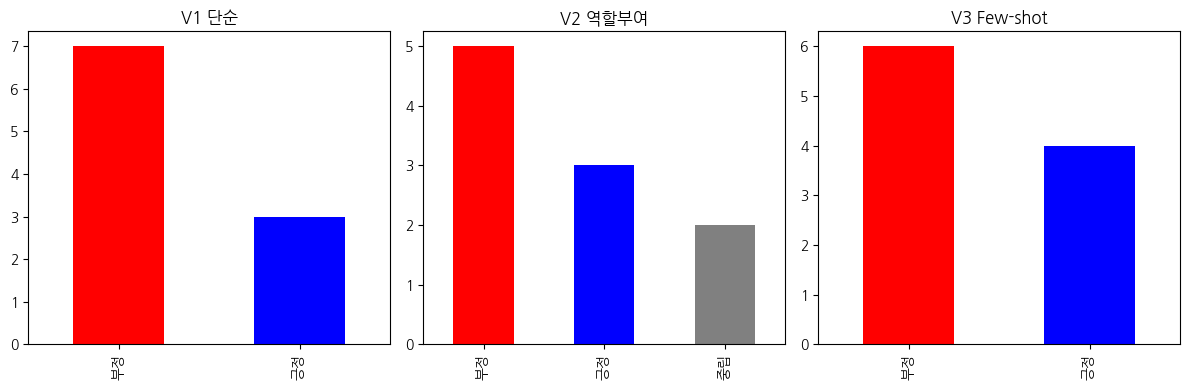

In [17]:
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rc('font', family='NanumGothic')  # 한글 폰트
matplotlib.font_manager._load_fontmanager(try_read_cache=False)


def extract_sentiment(text):
    if '긍정' in text:
        return '긍정'
    elif '부정' in text:
        return '부정'
    else:
        return '중립'

df['v1_label'] = df['v1_단순분류'].apply(extract_sentiment)
df['v2_label'] = df['v2_역할부여'].apply(extract_sentiment)
df['v3_label'] = df['v3_fewshot'].apply(extract_sentiment)

# 시각화
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, col, title in zip(axes, ['v1_label','v2_label','v3_label'], ['V1 단순','V2 역할부여','V3 Few-shot']):
    df[col].value_counts().plot(kind='bar', ax=ax, color=['red','blue','gray'])
    ax.set_title(title)
    ax.set_xlabel('')

plt.tight_layout()
plt.savefig('sentiment_comparison.png', dpi=150)
plt.show()

In [18]:
# CSV 저장
#df.to_csv("sentiment_analysis_results.csv", index=False, encoding="utf-8-sig")
#print("\nCSV 저장 완료!")